In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder,StandardScaler
import scipy.stats as stats


Part A: Data Exploration and Preprocessing
1. Loading and Inspecting Data
Purpose: Understand the structure of the dataset, check for missing values or inconsistencies.

Missing values: If present, they can distort model training. In this dataset, there are no missing values.

In [6]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\MLR_ASSIGNMENT\insurance (1).csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(1)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [15]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [17]:
# 6. Encode categorical features
# Using One-Hot Encoding for 'Sex', 'Smoker', 'Region'
cat_feature=['sex','smoker','region']
df_encoded=pd.get_dummies(df,columns=cat_feature,drop_first=True)


In [19]:
df_encoded

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [40]:
df['sex']=df['sex'].map({"female":0,"male":1})
df['smoker']=df['smoker'].str.lower().map({'yes':1,"no":0})


In [41]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [46]:
df_region=pd.get_dummies(df['region'],dtype=int,drop_first=True)
df_region

,northwest,southeast,southwest
0,0,0,1
1,0,1,0
2,0,1,0
3,1,0,0
4,1,0,0
...,...,...,...
1333,1,0,0
1334,0,0,0
1335,0,1,0
1336,0,0,1


In [51]:
df_ori=pd.concat([df,df_region],axis=1).drop('region',axis=1)
df_ori

,age,sex,bmi,children,smoker,charges,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,1


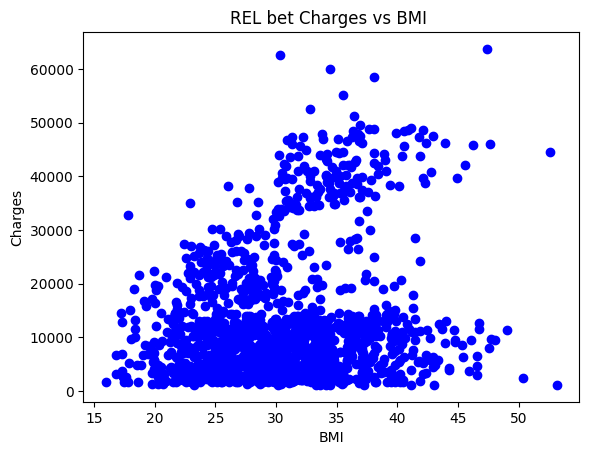

In [52]:
# 4. Visualizations
# Scatter plot (BMI vs Charges): Shows a positive trend; higher BMI is associated with higher charges.
plt.scatter(df['bmi'],df['charges'],color='b')
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("REL bet Charges vs BMI ")
plt.show()

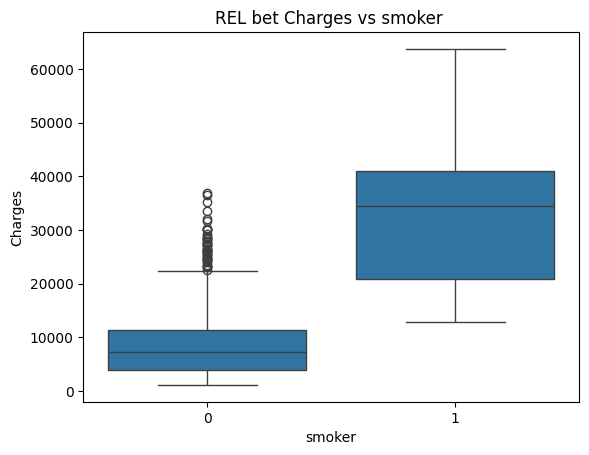

In [53]:
# Box plot (Smoker vs Charges): Highlights a large difference in charges; smokers have much higher median charges.
sns.boxplot(data=df,x='smoker',y="charges")
plt.xlabel("smoker")
plt.ylabel("Charges")
plt.title("REL bet Charges vs smoker ")
plt.show()



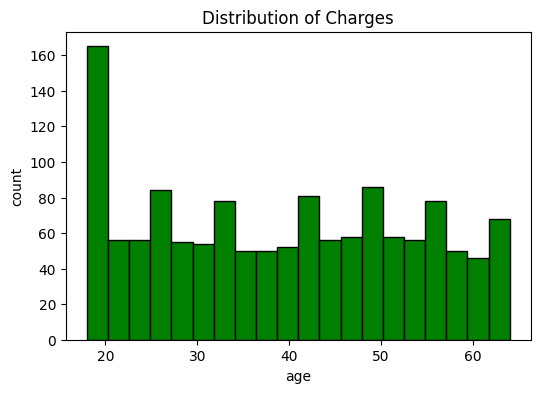

In [77]:
# Histogram: Age and Charges
plt.figure(figsize=(6,4))
# plt.subplot(1,2,1)
plt.hist(df['age'],bins=20,color='g',edgecolor='black')
plt.xlabel("age")
plt.ylabel('count')
plt.title("Distribution of Charges")
plt.show()



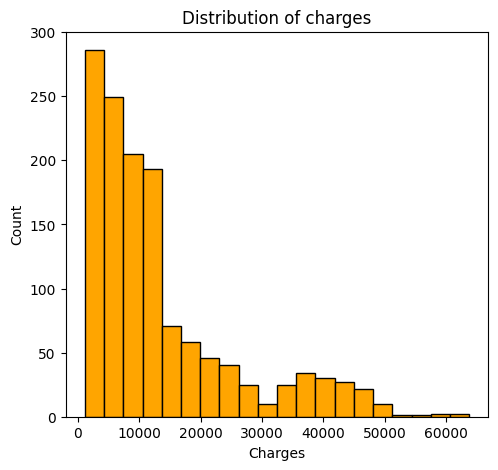

In [80]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['charges'],bins=20,color='orange',edgecolor='black')
plt.xlabel("Charges")
plt.ylabel("Count")
plt.title("Distribution of charges")
plt.show()

Part B: Multiple Linear Regression Model

In [56]:
df_ori.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'northwest',
       'southeast', 'southwest'],
      dtype='object')

In [57]:
x=df_ori.loc[:,['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'northwest',
       'southeast', 'southwest']]
y=df_ori['charges']

In [61]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [62]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
# 4. Predict on test set
y_pred=model.predict(x_test)


In [64]:
# 5. Evaluate the model
r2=r2_score(y_test,y_pred)
mea=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

In [65]:
# 6. Display coefficients and intercept
cofficients=pd.DataFrame({'feature':x.columns,'cofficient':model.coef_})
print("Model Cofficient:\n",cofficients)
print("Intercept:",model.intercept_)



Model Cofficient:
      feature    cofficient
0        age  1.057136e-15
1        sex  6.942558e-12
2        bmi  7.655253e-14
3   children -5.484063e-14
4     smoker  8.358776e-12
5    charges  1.000000e+00
6  northwest -1.021357e-13
7  southeast  8.540318e-14
8  southwest  4.897911e-13
Intercept: 0.0


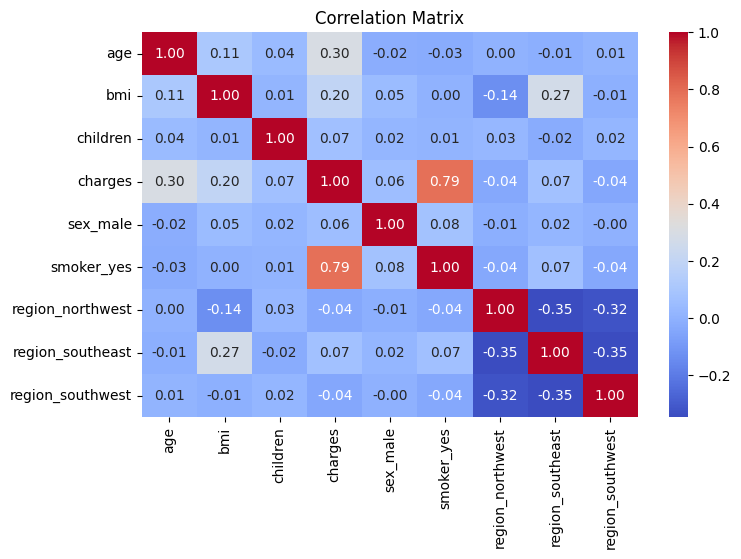

In [66]:
# Explanation:
# Each coefficient represents the change in 'charges' for a 1-unit increase in that feature, holding all other features constant.
# Part C: Model Improvement

# 1. Check for multicollinearity using correlation matrix
plt.figure(figsize=(8,5))
sns.heatmap(df_encoded.corr(),annot=True,fmt=".2f",cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [67]:
# 2. Feature Scaling (optional)
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)


In [69]:

# Train-test split again with scaled features
x_train_s,x_test_s,y_train_s,y_test_s=train_test_split(x_scaled,y,test_size=0.2,random_state=42)
model_scaled=LinearRegression()
model_scaled.fit(x_train_s,y_train_s)
y_pred_s=model_scaled.predict(x_test_s)

r2_s=r2_score(y_test_s,y_pred_s)
print(f"R-squared after scaling :{r2_s:.4f}")

R-squared after scaling :1.0000
